# Import

In [ ]:
import glob
import os
from tqdm import tqdm
from Bio import SeqIO
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import numpy as np

# Input processing

In [ ]:

folder = glob.glob('*')
if 'index.html' not in folder:
  !wget https://enterobase.warwick.ac.uk/schemes/Salmonella.wgMLST/
with open('index.html', 'r') as file:
  lines = file.readlines()
  for line in lines:
    if line.startswith('<a'):
      with open('fasta','a') as fa:
        fa.write(line.split('''href="''')[1].split('''">''')[0])
        fa.write('\n')
with open('fasta', 'r') as file:
  lines = file.readlines()
  for line in lines:
    e = len(line.split('.'))-1
    n = '.'.join(line.split('.')[:e])
    if n not in folder:

      !wget https://enterobase.warwick.ac.uk/schemes/Salmonella.wgMLST/{line}
      !gunzip {line}

In [ ]:

# This script scans all FASTA files in the directory to identify premature stop codons.
# It iterates through each sequence in the FASTA files, checking for stop codons (TAG, TAA, TGA)
# before the final triplet. If a stop codon is found, it records the sequence ID, the stop codon,
# and its position in the sequence. The process is parallelized for efficiency.

stop_codon = ['TAG','TAA','TGA']

all_fasta = glob.glob(f'Salmonella_izsler/*.fasta')

def tru(fasta):
  truncated = []


  records = list(SeqIO.parse(fasta, "fasta"))
  for rec in records:
      s = rec.seq
      triplets = [s[i:i+3] for i in range(0, len(s), 3)]
      triplets = triplets[:-1]
      for i, x in enumerate(triplets):
          if x in stop_codon:
              num = i*3+1
              truncated.append([rec.id, str(x), num])
              break
  return truncated
with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(tru, all_fasta), total=len(all_fasta), desc="Processing files"))
truncated = [item for sublist in results for item in sublist]

Processing files: 100%|██████████| 21067/21067 [19:26<00:00, 18.05it/s] 


In [ ]:

# This script processes the detected premature stop codons into a structured DataFrame.
# It extracts the gene name and allele from the sequence ID based on the number of underscore-separated elements.
# The processed DataFrame groups the results by gene, aggregating all detected alleles into lists.
# The final output allows for easy analysis of premature stop codon occurrences across different alleles.

truncated_df = pd.DataFrame(truncated, columns=['Gene','Stop_Codon','Position'])
truncated_df['Allele'] = truncated_df['Gene'].apply(lambda x: x.split('_')[1] if len(x.split('_')) < 3 else x.split('_')[2] if len(x.split('_')) < 4 else x.split('_')[3])
truncated_df['Gene'] = truncated_df['Gene'].apply(lambda x: x.split('_')[0] if len(x.split('_')) < 3 else '_'.join(x.split('_')[:2]) if len(x.split('_')) < 4 else '_'.join(x.split('_')[:3]) )
#truncated_df.to_csv('~/G_BIOSCIENZE/giovanni.merici/truncated.csv', index=False)
truncated_df = truncated_df.groupby('Gene')['Allele'].apply(list).reset_index()

In [ ]:

typhi = pd.read_csv('Salmonella_izsler/Typhimurium_prediction.csv')
rissen = pd.read_csv('Salmonella_izsler/Rissen_prediction.csv')
mono = pd.read_csv('Salmonella_izsler/Mono_prediction.csv')
ken = pd.read_csv('Salmonella_izsler/Kentucky_prediction.csv')
ent = pd.read_csv('Salmonella_izsler/Enteritidis_prediction.csv')
der = pd.read_csv('Salmonella_izsler/Derby_prediction.csv')
typhi_l = list(typhi['Name'])
rissen_l = list(rissen['Name'])
mono_l = list(mono['Name'])
ken_l = list(ken['Name'])
ent_l = list(ent['Name'])
der_l = list(der['Name'])

/tmp/ipykernel_45582/3663131618.py:1: DtypeWarning: Columns (48,69,108,117,118,120,144,146,154,159,217,232,233,250,259,260,261,271,272,287,312,313,314,315,316,342,343,348,351,352,356,368,369,370,371,372,373,374,375,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,400,401,402,403,404,405,406,407,408,409,410,413,414,420,421,424,440,450,451,455,459,460,468,469,471,472,482,483,486,488,489,491,493,494,495,497,498,499,500,501,503,504,505,507,516,517,574,576,602,605,606,607,612,614,621,622,674,681,682,712,714,715,717,719,724,725,726,727,728,729,730,735,742,744,745,751,753,754,755,756,761,764,765,766,768,769,770,771,772,776,777,801,806,1091,1092,1099,1100,1102,1115,1116,1117,1120,1238,1318,1319,1322,1323,1324,1325,1334,1338,1346,1347,1357,1359,1360,1365,1366,1369,1374,1375,1376,1377,1379,1380,1385,1387,1389,1391,1392,1395,1396,1398,1399,1401,1402,1404,1416,1438,1439,1441,1447,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457,1458,1459,1462,1463,1464,1465,1466,146

In [ ]:

#test matrix
der_as = pd.read_csv('Salmonella_izsler/Derby_Asia_m.csv', sep=';')
ken_as = pd.read_csv('Salmonella_izsler/Kentucky_Asia_m.csv', sep=';')
ent_as = pd.read_csv('Salmonella_izsler/Enteritidis_Asia_m.csv', sep=';')
ris_as = pd.read_csv('Salmonella_izsler/Rissen_Asia_m.csv', sep=';')
mono_as = pd.read_csv('Salmonella_izsler/Mono_Asia_m.csv', sep=';')
typhi_as = pd.read_csv('Salmonella_izsler/Typhimurium_Asia_m.csv',sep=';')
typhi_l = list(typhi_as['Name'])
rissen_l = list(ris_as['Name'])
mono_l = list(mono_as['Name'])
ken_l = list(ken_as['Name'])
ent_l = list(ent_as['Name'])
der_l = list(der_as['Name'])

/tmp/ipykernel_62357/1642234704.py:2: DtypeWarning: Columns (163,174,178,182,269,273,352,361,441,474,475,494,495,496,808,926,929,943,944,957,958,969,978,985,986,987,999,1000,1001,1002,1004,1005,1012,1026,1027,1029,1043,1055,1057,1058,1073,1086,1096,1133,1181,1183,1185,1190,1191,1193,1202,1213,1221,1223,1236,1240,1244,1248,1249,1250,1284,1285,1296,1301,1314,1331,1332,1336,1351,1356,1358,1363,1614,1675,1687,1749,1752,1757,1760,1816,1946,1966,1967,1973,1974,1997,2001,2002,2003,2011,2029,2032,2034,2035,2076,2077,2079,2083,2386,2387,2440,2445,2452,2465,2572,2592,2593,2594,2598,2606,2732,2741,2748,2756,2757,2758,2759,2760,2761,2773,2789,2805,2811,2812,2813,2814,2816,2817,2819,2820,2821,2822,2900,2907,2910,2931,2970,2990,3142,3159,3166,3195,3196,3197,3198,3199,3200,3207,3208,3209,3223,3246,3276,3280,3304,3322,3599,3728,3920,4031,4171,4172,4173,4174,4175,4176,4177,4178,4179,4180,4182,4282,4434,4514,4636,4897,4961,4970,4971,4983,5006,5085,5313,5314,5319,5320,5321,5322,5323,5325,5326,5327,5328,5

In [ ]:

der_swi_usa = pd.read_csv("Derby swine north america 130325.csv", sep=';')
ent_pou_usa = pd.read_csv("Enteritidis poultry north america 130325.csv", sep=';')
typ_bov_usa = pd.read_csv("Typhimurium bovine north america 130325.csv", sep=';')
typ_swi_usa = pd.read_csv("Typhimurium swine north america 130325 (1).csv", sep=';')
mono_swi_usa = pd.read_csv("Mono swine north america 130325 (1).csv", sep=';')
typ_pou_usa = pd.read_csv("Typhimurium poultry north america 130325.csv", sep=';')
mono_bov_usa = pd.read_csv("Mono bovine north america 130325 (1).csv", sep=';')
mono_pou_usa = pd.read_csv("Mono poultry north america 130325 (1).csv", sep=';')
ken_pou_usa_23 = pd.read_csv("Kentucky poultry north america 2023 130325.csv", sep=';')
ken_pou_usa_24  = pd.read_csv("Kentucky poultry north america 2024 130325.csv", sep=';')
ken_pou_usa_22  = pd.read_csv("Kentucky poultry north america 2022 130325.csv", sep=';')
ken_pou_usa_21  = pd.read_csv("Kentucky poultry north america 2021 130325.csv", sep=';')
ken_pou_usa_19  = pd.read_csv("Kentucky poultry north america 2019 211124.csv", sep=';')
ken_pou_usa_20  = pd.read_csv("Kentucky poultry north america 2020 130325.csv", sep=';')
ris_swi_usa = pd.read_csv("Rissen swine north america 211124.csv", sep=';')

/tmp/ipykernel_66498/878932262.py:1: DtypeWarning: Columns (144,145,153,154,155,157,160,167,168,169,220,226,258,266,277,378,392,399,400,402,403,404,405,406,407,408,423,424,425,749,750,871,872,888,890,896,904,906,909,918,933,935,936,946,947,948,962,963,965,966,968,970,975,978,981,986,987,989,997,1004,1007,1011,1012,1013,1014,1029,1041,1042,1055,1077,1084,1113,1114,1115,1116,1117,1118,1127,1129,1130,1131,1132,1133,1135,1141,1149,1150,1151,1156,1162,1174,1176,1188,1193,1195,1196,1202,1203,1204,1207,1208,1209,1210,1211,1212,1232,1234,1237,1238,1239,1240,1241,1242,1244,1247,1287,1290,1349,1367,1371,1372,1376,1377,1434,1446,1452,1456,1463,1516,1552,1591,1606,1607,1608,1609,1610,1611,1612,1613,1667,1771,1865,1877,1935,1938,1948,1954,2026,2038,2102,2196,2207,2233,2234,2240,2241,2246,2251,2259,2279,2285,2286,2287,2291,2309,2313,2314,2316,2319,2321,2322,2346,2348,2349,2350,2352,2353,2354,2355,2356,2625,2643,2644,2645,2646,2647,2648,2649,2663,2664,2721,2726,2727,2732,2737,2867,2872,2873,2882,2883

In [ ]:

# Europe files
ent_pou_eur = pd.read_csv("Enteritidis poultry europe 050325.csv", sep=';')
der_swi_eur = pd.read_csv("Derby swine europe 050325.csv", sep=';')
mono_swi_eur = pd.read_csv("Mono swine europe 060325 (1).csv", sep=';')
ken_pou_eur = pd.read_csv("Kentucky poultry europe 050325.csv", sep=';')
typ_swi_eur = pd.read_csv("Typhimurium swine europe 050325.csv", sep=';')
ris_swi_eur = pd.read_csv("Rissen swine europe 050325.csv", sep=';')
mono_pou_eur = pd.read_csv("Mono poultry europe 050325 (1).csv", sep=';')
typ_pou_eur = pd.read_csv("Typhimurium poultry europe 050325.csv", sep=';')
mono_bov_eur = pd.read_csv("Mono bovine europe 050325 (1).csv", sep=';')
typ_bov_eur = pd.read_csv("Typhimurium bovine europe 050325.csv", sep=';')

/tmp/ipykernel_66498/683043091.py:2: DtypeWarning: Columns (124,138,140,148,164,204,297,315,320,325,329,331,374,375,429,430,431,440,443,444,461,462,463,466,469,489,572,596,608,623,626,627,628,643,694,721,727,745,826,853,864,958,959,1004,1008,1009,1049,1050,1051,1068,1082,1104,1105,1113,1114,1116,1125,1126,1127,1131,1297,1299,1447,1473,1474,1475,1476,1477,1481,1482,1486,1487,1493,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509,1510,1511,1512,1517,1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557,1558,1559,1560,1565,1566,1567,1576,1577,1578,1661,1667,1672,1788,1791,1803,1851,1874,1878,1879,1883,1884,1885,1886,1887,1891,1894,1930,1988,1989,1990,1991,2100,2101,2146,2147,2148,2149,2150,2160,2161,2213,2214,2232,2233,2236,2238,2239,2240,2241,2242,2243,2244,2255,2256,2257,2258,2259,2261,2262,2308,2309,2310,2311,2312,2313,2314,2315,2316,2317,2318,2319,2320,2321,2322,2323,2324,2325,2326,2327,2328,2329,2330,2331,2332,2333,233

In [ ]:

# USA lists
der_swi_usa_l = list(der_swi_usa['Name'])
ent_pou_usa_l = list(ent_pou_usa['Name'])
typ_bov_usa_l = list(typ_bov_usa['Name'])
typ_swi_usa_l = list(typ_swi_usa['Name'])
mono_swi_usa_l = list(mono_swi_usa['Name'])
typ_pou_usa_l = list(typ_pou_usa['Name'])
mono_bov_usa_l = list(mono_bov_usa['Name'])
mono_pou_usa_l = list(mono_pou_usa['Name'])
ken_pou_usa_23_l = list(ken_pou_usa_23['Name'])
ken_pou_usa_24_l = list(ken_pou_usa_24['Name'])
ken_pou_usa_22_l = list(ken_pou_usa_22['Name'])
ken_pou_usa_21_l = list(ken_pou_usa_21['Name'])
ken_pou_usa_19_l = list(ken_pou_usa_19['Name'])
ken_pou_usa_20_l = list(ken_pou_usa_20['Name'])
ris_swi_usa_l = list(ris_swi_usa['Name'])

# Europe lists
ent_pou_eur_l = list(ent_pou_eur['Name'])
der_swi_eur_l = list(der_swi_eur['Name'])
mono_swi_eur_l = list(mono_swi_eur['Name'])
ken_pou_eur_l = list(ken_pou_eur['Name'])
typ_swi_eur_l = list(typ_swi_eur['Name'])
ris_swi_eur_l = list(ris_swi_eur['Name'])
mono_pou_eur_l = list(mono_pou_eur['Name'])
typ_pou_eur_l = list(typ_pou_eur['Name'])
mono_bov_eur_l = list(mono_bov_eur['Name'])
typ_bov_eur_l = list(typ_bov_eur['Name'])

In [ ]:

matrices = [typhi,rissen,mono,ent, der, ken]

matrix = pd.concat(matrices).fillna(0)
matrix = matrix.astype(str)

matrix = matrix.drop_duplicates('Name')
matrix = matrix[matrix['Name'] != 'Kentucky']
matrix = matrix[matrix['Name'] != 'Derby']

def check_values(val):
    if isinstance(val, float):
        return "float"
    elif val in ['-', '-1', '-1.0']:
        return "special string"
    elif isinstance(val, int):
        return "int"
    elif isinstance(val, str):
        return "string"
    else:
        return "other"

# Apply function to the entire DataFrame
df_checked = matrix.applymap(check_values)

print(df_checked)
matrix.replace('-', 0, inplace=True)
matrix.replace('-1', 0, inplace=True)
matrix.replace('-1.0', 0, inplace=True)
matrix = matrix.drop(columns=['ST'])
matrix.reset_index(drop=True, inplace=True)
vir = []
for name in matrix['Name']:
    #if name in typhi_l or name in ent_l or name in mono_l or name in typhi2_l or name in ent2_l or name in mono2_l:
    #if name in der_l or name in rissen_l or name in ken_l or name :
    if name in mono_l or name in typhi_l or name in ent_l: #or name in der_l_h or name in rissen_l_h or name in ken_l_h:
        vir.append(1)
    else:
        vir.append(0)
matrix['Virulence'] = vir
for col in matrix.columns:
    if col not in ['Name']:  # Skip these columns
        matrix[col] = pd.to_numeric(matrix[col], errors='coerce')
        matrix[col] = matrix[col].astype(int)

matrix.fillna(0, inplace=True)
df_checked = matrix.applymap(check_values)
print(df_checked)
#matrix.iloc[:, 1:] = matrix.iloc[:, 1:].astype(float)
#matrix.iloc[:, 1:] = matrix.iloc[:, 1:].astype(int)
#matrix.iloc[:, 1:] = matrix.iloc[:, 1:].round().astype(int)

/tmp/ipykernel_45582/1799669221.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_checked = matrix.applymap(check_values)


       Name      ST 32473_B02_04468 32473_B02_04469 32473_B02_04470  \
0    string  string  special string  special string  special string   
1    string  string  special string  special string  special string   
2    string  string  special string  special string  special string   
3    string  string  special string  special string  special string   
4    string  string  special string  special string  special string   
..      ...     ...             ...             ...             ...   
263  string  string          string          string          string   
264  string  string          string          string          string   
265  string  string          string          string          string   
266  string  string          string          string          string   
267  string  string          string          string          string   

    32473_B02_04477 32473_B02_04478 32473_B02_04479 32473_B02_04480  \
0    special string  special string  special string  special string   
1    

/tmp/ipykernel_45582/1799669221.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  matrix.replace('-1', 0, inplace=True)
/tmp/ipykernel_45582/1799669221.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix['Virulence'] = vir
/tmp/ipykernel_45582/1799669221.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_checked = matrix.applymap(check_values)


        Name 32473_B02_04468 32473_B02_04469 32473_B02_04470 32473_B02_04477  \
0     string             int             int             int             int   
1     string             int             int             int             int   
2     string             int             int             int             int   
3     string             int             int             int             int   
4     string             int             int             int             int   
...      ...             ...             ...             ...             ...   
1703  string             int             int             int             int   
1704  string             int             int             int             int   
1705  string             int             int             int             int   
1706  string             int             int             int             int   
1707  string             int             int             int             int   

     32473_B02_04478 32473_B02_04479 32

In [ ]:

#now article
stopgenes = 0

for gene in tqdm(matrix.columns[1:-1], total=len(matrix.columns), desc=f"Converting to 1s and 0s"):

    if gene in truncated_df['Gene'].values:
        stopgenes = stopgenes+1

        df = truncated_df.loc[truncated_df['Gene'] == gene, 'Allele'].iloc[0]
        matrix[gene] = matrix[gene].apply(lambda x: 0 if str(x) in df else x)
        matrix[gene] = matrix[gene].apply(lambda x: 1 if x != 0 else 0)

    else:

        matrix[gene] = matrix[gene].apply(lambda x: 1 if x != 0 else 0)

print(stopgenes/len(matrix.columns)*100)

Converting to 1s and 0s: 100%|█████████▉| 15648/15650 [01:01<00:00, 254.73it/s]

81.24600638977635


In [ ]:
#now article
for i, name in enumerate(matrix['Name']):

    if name in typhi_l:
        matrix['Name'].iloc[i] = 'typhimurium'

    elif name in rissen_l:
        matrix['Name'].iloc[i] = 'rissen'
    #elif name in typhi_l_a:
    #    matrix['Name'].iloc[i] = 'typhimurium_animal'

    elif name in mono_l:
        matrix['Name'].iloc[i] = 'mono'

    #elif name in mono_l_a:
      #  matrix['Name'].iloc[i] = 'mono_animal'

    elif name in ken_l:
        matrix['Name'].iloc[i] = 'ken'

    elif name in ent_l:
        matrix['Name'].iloc[i] = 'ent'
   # elif name in ent_l_a:
      #  matrix['Name'].iloc[i] = 'ent_animal'

    elif name in der_l:
        matrix['Name'].iloc[i] = 'der'
#
  #  elif name in der_l_h:
  #      matrix['Name'].iloc[i] = 'der_human'

 #   elif name in rissen_l_h:
 #       matrix['Name'].iloc[i] = 'rissen_human'

 #   elif name in ken_l_h:
    #    matrix['Name'].iloc[i] = 'ken_human'
    #elif name in typhi2_l:
    #    matrix['Name'].iloc[i] = 'typhimurium2'
   # elif name in mono2_l:
   #     matrix['Name'].iloc[i] = 'mono2'
  #  elif name in ent2_l:
   #     matrix['Name'].iloc[i] = 'ent2'
    #elif name in typhii_l:
      #  matrix['Name'].iloc[i] = 'typhi'


    #elif name in dub_l:
     #   matrix['Name'].iloc[i] = 'dublin'
 #   elif name in ana_l:
#        matrix['Name'].iloc[i] = 'Anatum'
#    elif name in inf_l:
#        matrix['Name'].iloc[i] = 'infantis'
#    elif name in chole_l:
#        matrix['Name'].iloc[i] = 'Chole'
    #elif name in para_l:
       # matrix['Name'].iloc[i] = 'para'

matrix = matrix.loc[:, (matrix != 0).any() & (matrix != 1).any()]
matrix = matrix.drop_duplicates(subset=matrix.columns.difference(['Name']))

/tmp/ipykernel_45582/262017207.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  matrix['Name'].iloc[i] = 'typhimurium'
/tmp/ipykernel_45582/262017207.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

# Random Forest for virulence

Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 200, 'max_features': None, 'max_depth': 30}
oob Score: 0.9351851851851852
Accuracy Score: 0.8583333333333333


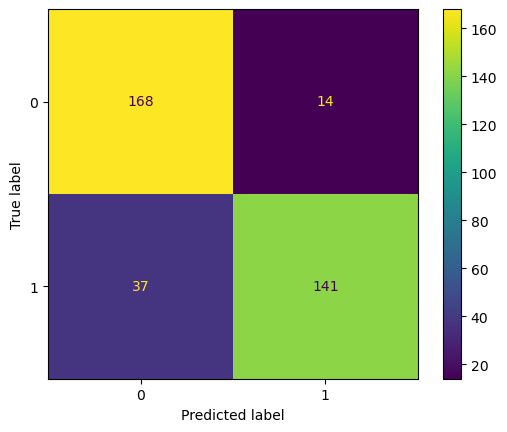

In [ ]:

df = matrix
X = df.iloc[:,:-1]
X = X.iloc[:,1:]
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

param_dist = {
    'n_estimators': [10, 50, 100, 200, 300,400,500,600,800,900,1000],  # Number of trees
    'max_depth': [None, 10, 20, 30, 50,100,200,300,400],  # Tree depth
    'min_samples_split': [2, 5, 10,20,30],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5,10,20,30],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [None, 10, 50, 100, 200, 300]
}

param_dist = {
    'n_estimators': [10, 50, 100, 200, 300, 400, 500],  # Number of trees
    'max_depth': [30, 50,100,200,300,400],  # Tree depth
    'min_samples_split': [2, 5, 10,20,30],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5,10,20,30],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [ 10, 50, 100, 200, 300]
}


rf = RandomForestClassifier(random_state=0)


rand_search = RandomizedSearchCV(rf,
                                 param_distributions = param_dist,
                                 n_iter=5,
                                 cv=5,
                                 random_state=0,
                                 n_jobs=-1,
                                 verbose=1
                                 )

rand_search.fit(X_train, y_train)

best_params = rand_search.best_params_
print(best_params)
d = best_params['max_depth']
f = best_params['max_features']
n = best_params['max_leaf_nodes']
e = best_params['n_estimators']
u = best_params['min_samples_split']
j = best_params['min_samples_leaf']
rf = RandomForestClassifier(n_estimators=e, max_depth=d, max_features=f, max_leaf_nodes=n, min_samples_split=u, min_samples_leaf=j, random_state=0, oob_score=True)


rf.fit(X_train, y_train)
preds = rf.predict(X_test)
print(f"oob Score: {rf.oob_score_}")
print(f"Accuracy Score: {accuracy_score(y_test, preds)}")
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

Fitting 5 folds for each of 5 candidates, totalling 25 fits
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': 50, 'max_features': 'log2', 'max_depth': None}
OOB Score: 1.0
Cross-validation scores: [1. 1. 1. 1. 1.]
Mean CV score: 1.0
oob Score: 1.0
Accuracy Score: 1.0
kappa value: 1.0


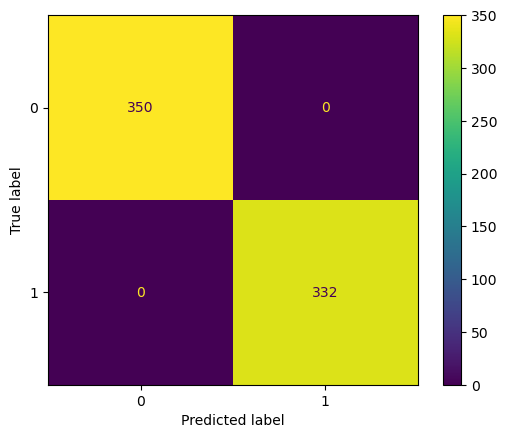

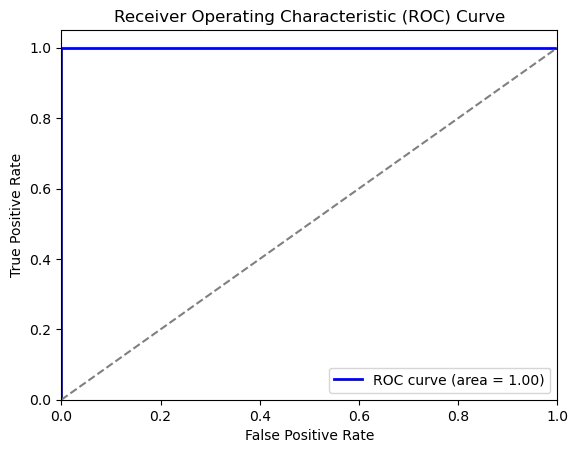

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import cohen_kappa_score

# Assuming df is already defined
df = matrix
#df = pred_df
#X = df.iloc[:, 1:-1]  # Skipping the first column
y = df.iloc[:,-1]
X = df.iloc[:,1:-1]
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

param_dist = {
    'n_estimators': [10, 50, 100, 200, 300,400,500,600,800,900,1000],  # Number of trees
    'max_depth': [None, 10, 20, 30, 50,100,200,300,400],  # Tree depth
    'min_samples_split': [2, 5, 10,20,30],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5,10,20,30],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': [None, 10, 50, 100, 200, 300]
}

#param_dist = {
#    'n_estimators': [10, 50, 100, 200, 300,400,500,600,800,900,1000],  # Number of trees
#    'max_depth': [None, 10, 20, 30, 50,100,200,300,400,500,600,700,800],  # Tree depth
#    'min_samples_split': [2, 5, 10,20,30,40,50,60],  # Minimum samples to split a node
#    'min_samples_leaf': [1, 2, 5,10,20,30,40,50,60],  # Minimum samples per leaf
#    'max_features': ['sqrt', 'log2', None],
#    'max_leaf_nodes': [None, 10, 50, 100, 200, 300,400,500]
#}

rf = RandomForestClassifier(random_state=0)


rand_search = RandomizedSearchCV(rf,
                                 param_distributions = param_dist,
                                 #n_iter=5,
                                 n_iter=5,
                                 cv=5,
                                 random_state=0,
                                 n_jobs=-1,
                                 verbose=1
                                 )

rand_search.fit(X_train, y_train)

best_params = rand_search.best_params_
print(best_params)
d = best_params['max_depth']
f = best_params['max_features']
n = best_params['max_leaf_nodes']
e = best_params['n_estimators']
u = best_params['min_samples_split']
j = best_params['min_samples_leaf']
rf = RandomForestClassifier(n_estimators=e, max_depth=d, max_features=f, max_leaf_nodes=n, min_samples_split=u, min_samples_leaf=j, random_state=0, oob_score=True, n_jobs=-1)


# Initializing the RandomForestClassifier
#rf = RandomForestClassifier(n_estimators=200, max_depth=50, max_features=None,
#                            max_leaf_nodes=50, min_samples_split=2,
#                            min_samples_leaf=2, random_state=0, oob_score=True)

# Fitting the model
rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)

# Perform cross-validation on training data only (not test data)
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

# Making predictions
preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC

# Printing scores
print(f"oob Score: {rf.oob_score_}")
print(f"Accuracy Score: {accuracy_score(y_test, preds)}")


kappa = cohen_kappa_score(y_test, preds)
print(f"kappa value: {kappa}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

## Important genes

In [ ]:

names = matrix.columns[1:-1]
im = rf.feature_importances_
im_df = pd.DataFrame({'Im': im, 'feat': names})
r = im_df[im_df['Im'] > 0].sort_values('Im', ascending=False).reset_index(drop=True)
r

,Im,feat
0,1.152258e-02,STMMW_09051
1,1.043349e-02,STMMW_29961
2,8.854227e-03,SEHA_RS01365
3,8.475312e-03,STMMW_30811
4,8.117635e-03,SNSL254_RS11435
...,...,...
1698,1.580692e-09,NCTC8258_03512
1699,1.508952e-09,CFSAN002050_RS25000
1700,1.412361e-09,SAL_EA0782AA_03848
1701,1.149399e-09,SAL_DA2273AA_00314


# Supplementary random-control analyses

These cells were in the original notebook but were not included in the first GitHub draft. They are kept here as optional validation rather than as part of the main manuscript workflow.

They test two different null models:

1. **Label-shuffle control**: keep the same gene matrix, but randomly permute the virulent/attenuated labels.
2. **Random 22-gene-set control**: keep the true labels, but replace the selected 22-gene set with random 22-gene subsets.

Run these only after the main Random Forest section has created `matrix`, `X`, `y`, `X_train`, `X_test`, `y_train`, `y_test`, `rf`, and `r`.

In [ ]:
# Supplementary control settings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 0
N_LABEL_SHUFFLES = 1000
N_RANDOM_GENE_SETS = 10000
N_JOBS = -1

RESULTS_DIR = Path("results/random_controls")
FIGURES_DIR = Path("results/figures/random_controls")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reuse the tuned RF if it already exists; otherwise use the manuscript parameters.
try:
    rf_params = rf.get_params()
except NameError:
    rf_params = dict(
        n_estimators=300,
        max_depth=None,
        max_features="log2",
        max_leaf_nodes=50,
        min_samples_split=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        oob_score=True,
        n_jobs=N_JOBS,
    )

# Keep only RandomForestClassifier parameters, in case the existing object contains unsupported extras.
rf_template = RandomForestClassifier(**{
    "n_estimators": rf_params.get("n_estimators", 300),
    "max_depth": rf_params.get("max_depth", None),
    "max_features": rf_params.get("max_features", "log2"),
    "max_leaf_nodes": rf_params.get("max_leaf_nodes", 50),
    "min_samples_split": rf_params.get("min_samples_split", 20),
    "min_samples_leaf": rf_params.get("min_samples_leaf", 2),
    "random_state": RANDOM_STATE,
    "oob_score": True,
    "n_jobs": N_JOBS,
})

# Standard predictors and labels used by the manuscript RF analysis.
analysis_df = matrix.copy()
X = analysis_df.iloc[:, 1:-1]
y = analysis_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)


## 1. Label-shuffle control

This checks whether high RF performance can still be obtained after the class labels are broken. The matrix is unchanged, but `y` is shuffled before each train/test split.

In [ ]:
label_shuffle_rows = []
label_shuffle_roc = []

for seed in range(N_LABEL_SHUFFLES):
    y_shuffled = y.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    X_reset = X.reset_index(drop=True)

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_reset, y_shuffled, test_size=0.4, random_state=RANDOM_STATE
    )

    model = clone(rf_template)
    model.set_params(random_state=seed)
    model.fit(X_train_s, y_train_s)

    y_pred_s = model.predict(X_test_s)
    y_prob_s = model.predict_proba(X_test_s)[:, 1]
    fpr_s, tpr_s, _ = roc_curve(y_test_s, y_prob_s)
    auc_s = auc(fpr_s, tpr_s)

    label_shuffle_rows.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test_s, y_pred_s),
        "auc": auc_s,
        "oob_score": getattr(model, "oob_score_", np.nan),
    })
    label_shuffle_roc.append({"seed": seed, "fpr": fpr_s, "tpr": tpr_s})

label_shuffle_results = pd.DataFrame(label_shuffle_rows)
label_shuffle_results.to_csv(RESULTS_DIR / "label_shuffle_results.csv", index=False)

label_shuffle_results.describe()


In [ ]:
# Plot label-shuffle null distributions.
for metric, real_value in {"accuracy": 1.0, "auc": 1.0, "oob_score": 1.0}.items():
    values = label_shuffle_results[metric].dropna().to_numpy()
    p_value = np.mean(values >= real_value)

    plt.figure(figsize=(7, 5))
    plt.hist(values, bins=30, alpha=0.8)
    plt.axvline(real_value, linestyle="--", linewidth=2, label=f"Real model {metric}=1.0")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.title(f"Label-shuffle null distribution: {metric}\nEmpirical p={p_value:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"label_shuffle_{metric}.png", dpi=300)
    plt.show()

plt.figure(figsize=(7, 6))
for row in label_shuffle_roc:
    plt.plot(row["fpr"], row["tpr"], alpha=0.08, linewidth=1)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves from label-shuffled controls")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_shuffle_roc_curves.png", dpi=300)
plt.show()


## 2. Random 22-gene-set control

This checks whether the selected 22-gene set performs better than arbitrary gene sets of the same size. It keeps the true labels but repeatedly samples 22 random genes from the full feature matrix.

`selected_22_genes` should contain the 22 final discriminative loci. If it is not already defined, the cell below tries to use the first 22 genes in `r`, the RF importance table.

In [ ]:
# Define the real 22-gene set.
# Preferred: define selected_22_genes explicitly from the final 22-gene output table.
try:
    selected_22_genes
except NameError:
    if "r" in globals() and isinstance(r, pd.DataFrame) and "feat" in r.columns:
        selected_22_genes = r.sort_values("Im", ascending=False)["feat"].head(22).tolist()
    else:
        raise NameError(
            "Define selected_22_genes before running this cell, or run the RF importance section that creates r."
        )

selected_22_genes = list(selected_22_genes)
assert len(selected_22_genes) == 22, f"Expected 22 genes, found {len(selected_22_genes)}"

# Train/evaluate the real 22-gene model.
X22 = X[selected_22_genes]
X22_train, X22_test, y22_train, y22_test = train_test_split(
    X22, y, test_size=0.4, random_state=RANDOM_STATE
)

real_22_model = clone(rf_template)
real_22_model.fit(X22_train, y22_train)
real_22_pred = real_22_model.predict(X22_test)
real_22_prob = real_22_model.predict_proba(X22_test)[:, 1]

real_22_metrics = {
    "accuracy": accuracy_score(y22_test, real_22_pred),
    "auc": roc_auc_score(y22_test, real_22_prob),
    "oob_score": getattr(real_22_model, "oob_score_", np.nan),
    "mean_cv": cross_val_score(real_22_model, X22_train, y22_train, cv=5, scoring="accuracy", n_jobs=N_JOBS).mean(),
}
real_22_metrics


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
all_gene_columns = np.array([gene for gene in X.columns if gene not in selected_22_genes])
random_gene_rows = []
random_gene_roc = []

for i in range(N_RANDOM_GENE_SETS):
    sampled_genes = rng.choice(all_gene_columns, size=22, replace=False).tolist()
    Xi = X[sampled_genes]

    Xi_train, Xi_test, yi_train, yi_test = train_test_split(
        Xi, y, test_size=0.4, random_state=RANDOM_STATE
    )

    model = clone(rf_template)
    model.set_params(random_state=int(i))
    model.fit(Xi_train, yi_train)

    pred_i = model.predict(Xi_test)
    prob_i = model.predict_proba(Xi_test)[:, 1]
    fpr_i, tpr_i, _ = roc_curve(yi_test, prob_i)
    auc_i = auc(fpr_i, tpr_i)

    random_gene_rows.append({
        "iteration": i,
        "accuracy": accuracy_score(yi_test, pred_i),
        "auc": auc_i,
        "oob_score": getattr(model, "oob_score_", np.nan),
        "mean_cv": cross_val_score(model, Xi_train, yi_train, cv=5, scoring="accuracy", n_jobs=N_JOBS).mean(),
        "genes": ";".join(sampled_genes),
    })
    random_gene_roc.append({"iteration": i, "fpr": fpr_i, "tpr": tpr_i})

random_22_gene_results = pd.DataFrame(random_gene_rows)
random_22_gene_results.to_csv(RESULTS_DIR / "random_22_gene_set_results.csv", index=False)

random_22_gene_results.describe()


In [ ]:
# Plot random-22-gene null distributions and empirical p-values.
for metric, real_value in real_22_metrics.items():
    values = random_22_gene_results[metric].dropna().to_numpy()
    p_value = np.mean(values >= real_value)

    plt.figure(figsize=(7, 5))
    plt.hist(values, bins=30, alpha=0.8)
    plt.axvline(real_value, linestyle="--", linewidth=2, label=f"Selected 22 genes {metric}={real_value:.3f}")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.title(f"Random 22-gene-set null distribution: {metric}\nEmpirical p={p_value:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"random_22_gene_sets_{metric}.png", dpi=300)
    plt.show()

plt.figure(figsize=(7, 6))
for row in random_gene_roc[:1000]:
    plt.plot(row["fpr"], row["tpr"], alpha=0.08, linewidth=1)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves from random 22-gene-set controls")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_22_gene_sets_roc_curves.png", dpi=300)
plt.show()


In [ ]:
# REVIEW: GitHub draft cell. Check relative paths and upstream variables before running end-to-end.
from sklearn.decomposition import PCA
import pandas as pd

X = df.iloc[:, 1:-1]  # binary matrix (no scaling)

pca = PCA(n_components=5, random_state=0)
pca.fit(X)

pc1_loadings = pd.Series(pca.components_[0], index=X.columns)
pc1_sorted = pc1_loadings.abs().sort_values(ascending=False).reset_index()
pc1_sorted.columns = ["feat", "abs_loading"]

print(pc1_sorted.head(20))  # top PC1 genes

               feat  abs_loading
0       STMMW_29961     0.051486
1   SNSL254_RS11435     0.051481
2   SNSL254_RS11460     0.051481
3   SNSL254_RS11450     0.051481
4    NCTC7295_03050     0.051481
5       STMMW_30801     0.051481
6       STMMW_30811     0.051481
7       STMMW_09081     0.051481
8       STMMW_30791     0.051465
9       STMMW_30771     0.051464
10        T_RS03710     0.051453
11  SNSL254_RS11440     0.051434
12  SNSL254_RS11445     0.051429
13      STMMW_09821     0.051426
14      STMMW_30781     0.051419
15      STMMW_09101     0.051407
16      STMMW_30831     0.051406
17      STMMW_09051     0.051403
18      STMMW_30821     0.051396
19      STMMW_09111     0.051396


Number of RF genes: 1703
Number of SVM genes: 6429
Number of PC1 genes: 9450
RF ∩ SVM: 1623
RF ∩ PC1: 1703
SVM ∩ PC1: 6429
All three: 1623


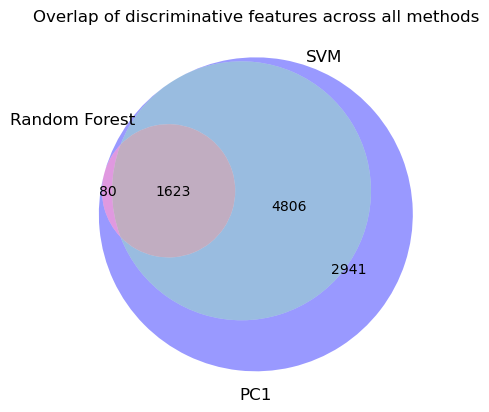

In [ ]:

rf_all = set(r[r["Im"] > 0]["feat"])

# --- SVM: all genes with non-zero coefficient
svm_all = set(svm_importances[svm_importances["abs_coef"] > 0]["feat"])

# --- PCA: all genes with non-zero PC1 loading
pc1_all = set(pc1_loadings[pc1_loadings != 0].index)

print("Number of RF genes:", len(rf_all))
print("Number of SVM genes:", len(svm_all))
print("Number of PC1 genes:", len(pc1_all))

# Overlaps
print("RF ∩ SVM:", len(rf_all & svm_all))
print("RF ∩ PC1:", len(rf_all & pc1_all))
print("SVM ∩ PC1:", len(svm_all & pc1_all))
print("All three:", len(rf_all & svm_all & pc1_all))

# --- Venn diagram ---
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

venn3([rf_all, svm_all, pc1_all],
      set_labels=("Random Forest", "SVM", "PC1"))
plt.title("Overlap of discriminative features across all methods")
plt.show()

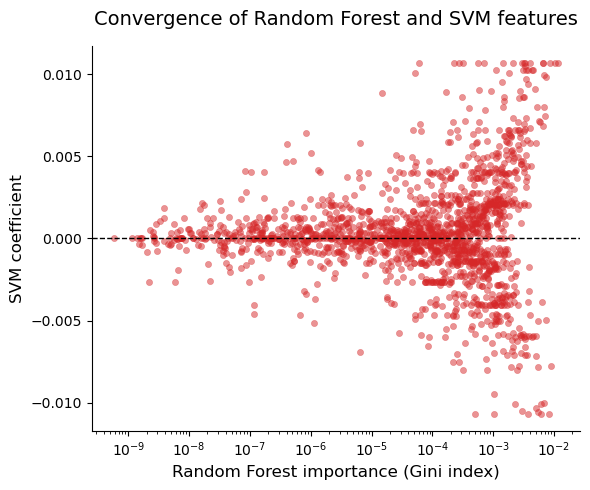

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Example: RF vs SVM
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=rf_svm_signed,
    x="Im",
    y="coef",
    s=20,             # smaller point size
    alpha=0.5,        # more transparency to reduce overplotting
    edgecolor=None,
    color="tab:red"
)

# Reference line
plt.axhline(0, color="black", linestyle="--", lw=1)

# Log scale for RF if values are very skewed
plt.xscale("log")

# Labels and style
plt.xlabel("Random Forest importance (Gini index)", fontsize=12)
plt.ylabel("SVM coefficient", fontsize=12)
plt.title("Convergence of Random Forest and SVM features", fontsize=14, pad=15)

sns.despine()  # remove top/right spines

plt.tight_layout()
plt.savefig('salmonella_article_graph/overlap_important_features_scatter_rf_svm.png', dpi=300)

plt.show()


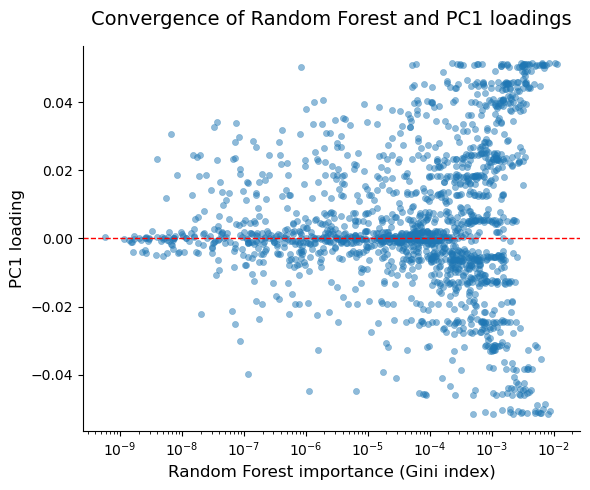

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Example: RF vs PC1
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=rf_pc1_merged,
    x="Im",
    y="pc1_loading",
    s=20,             # smaller point size
    alpha=0.5,        # more transparency to reduce overplotting
    edgecolor=None,
    color="tab:blue"
)

# Reference line
plt.axhline(0, color="red", linestyle="--", lw=1)

# Log scale for RF if values are very skewed
plt.xscale("log")

# Labels and style
plt.xlabel("Random Forest importance (Gini index)", fontsize=12)
plt.ylabel("PC1 loading", fontsize=12)
plt.title("Convergence of Random Forest and PC1 loadings", fontsize=14, pad=15)

sns.despine()  # remove top/right spines
plt.tight_layout()
plt.savefig('salmonella_article_graph/overlap_important_features_scatter_rf_pc1.png', dpi=300)
plt.show()


# Kmeans

/tmp/ipykernel_49052/1988306412.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=X_reduced_df, x="Group", y="PC1", inner="box", palette="muted")


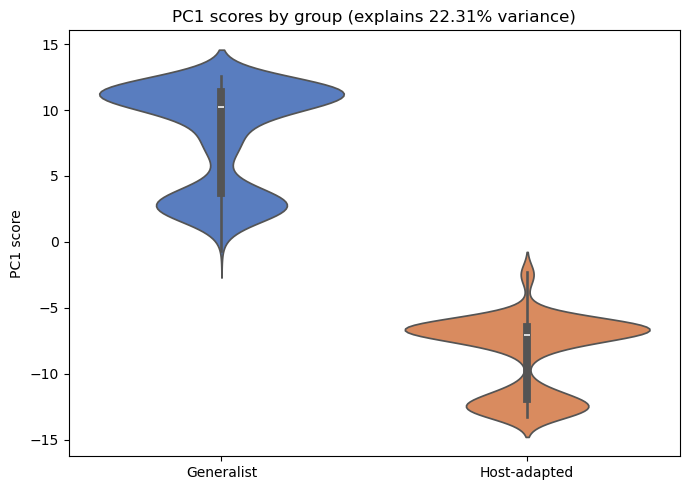

Mann–Whitney U test: U=724870.0, p=1.700e-279


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA

# --- PCA ---
X = df.iloc[:, 1:-2]   # adjust columns as in your earlier code
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

X_reduced_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2"])
X_reduced_df["Name"] = df["Name"].reset_index(drop=True)
X_reduced_df["Virulence"] = df["Virulence"].reset_index(drop=True)  # 1 = generalist, 0 = host-adapted

# --- Map Virulence column to group names ---
X_reduced_df["Group"] = X_reduced_df["Virulence"].map({1: "Generalist", 0: "Host-adapted"})

# --- Plot violin/boxplot of PC1 scores ---
plt.figure(figsize=(7, 5))
sns.violinplot(data=X_reduced_df, x="Group", y="PC1", inner="box", palette="muted")
plt.title(f"PC1 scores by group (explains {pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel("PC1 score")
plt.xlabel("")
plt.tight_layout()
plt.show()

# --- Mann–Whitney U test ---
pc1_generalist = X_reduced_df.loc[X_reduced_df["Virulence"] == 1, "PC1"]
pc1_host = X_reduced_df.loc[X_reduced_df["Virulence"] == 0, "PC1"]

stat, pval = mannwhitneyu(pc1_generalist, pc1_host, alternative="two-sided")
print(f"Mann–Whitney U test: U={stat}, p={pval:.3e}")


0.8467592550527127 0.8827809330611875
0.8467592550527127 0.8827809330611877
0.8467592550527127 0.8827809330611877
0.8467592550527127 0.8827809330611878
0.8467592550527127 0.8827809330611877
0.8467592550527127 0.8827809330611875
0.8467592550527127 0.8827809330611877
0.8467592550527127 0.8827809330611875
0.8467592550527127 0.8827809330611875
0.8467592550527127 0.8827809330611878
                ARI           NMI
count  1.000000e+01  1.000000e+01
mean   8.467593e-01  8.827809e-01
std    1.170278e-16  1.281975e-16
min    8.467593e-01  8.827809e-01
25%    8.467593e-01  8.827809e-01
50%    8.467593e-01  8.827809e-01
75%    8.467593e-01  8.827809e-01
max    8.467593e-01  8.827809e-01


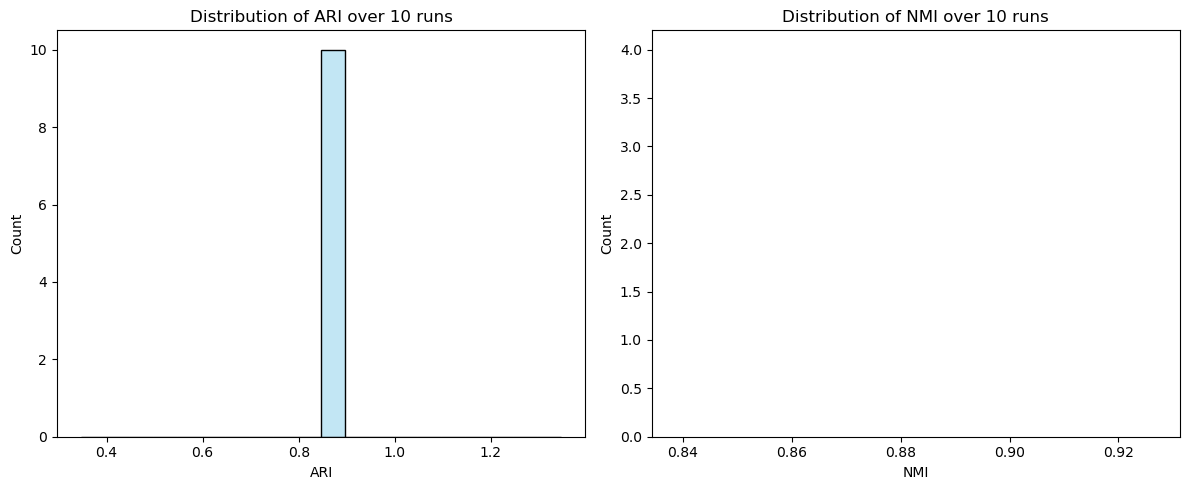

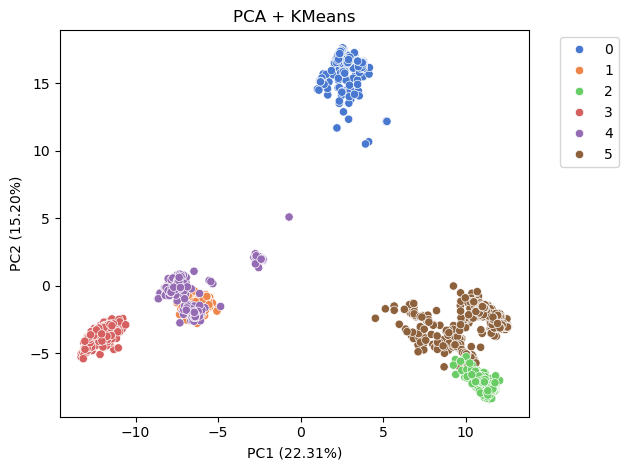

In [ ]:

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Data preparation ---
df = matrix.copy()
df['Group'] = df['Name']
X = df.iloc[:, 1:-2]   # drop first and last col; adjust if needed

# --- PCA for visualization ---
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

X_reduced_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2"])
X_reduced_df["Name"] = matrix["Name"].reset_index(drop=True)
X_reduced_df["Group"] = df["Group"].reset_index(drop=True)

# --- Repeat K-means 1000 times ---
results = []
for i in range(10):
    kmeans = KMeans(n_clusters=6, n_init=10, random_state=i).fit(X)
    labels = kmeans.labels_
    ari = adjusted_rand_score(df["Group"], labels)
    nmi = normalized_mutual_info_score(df["Group"], labels)
    print(ari, nmi)
    results.append([ari, nmi])

# --- Convert to DataFrame ---
results_df = pd.DataFrame(results, columns=["ARI", "NMI"])

# --- Print summary statistics ---
print(results_df.describe())

# --- Plot distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(results_df["ARI"], bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of ARI over 10 runs")
axes[0].set_xlabel("ARI")

sns.histplot(results_df["NMI"], bins=20, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Distribution of NMI over 10 runs")
axes[1].set_xlabel("NMI")

plt.tight_layout()
plt.show()

# --- PCA plot with one example clustering ---
best_run = results_df["ARI"].idxmax()
kmeans = KMeans(n_clusters=6, n_init=10, random_state=best_run).fit(X)
X_reduced_df["Cluster"] = kmeans.labels_

sns.scatterplot(data=X_reduced_df, x="PC1", y="PC2", hue="Cluster", palette="muted")
plt.title("PCA + KMeans")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


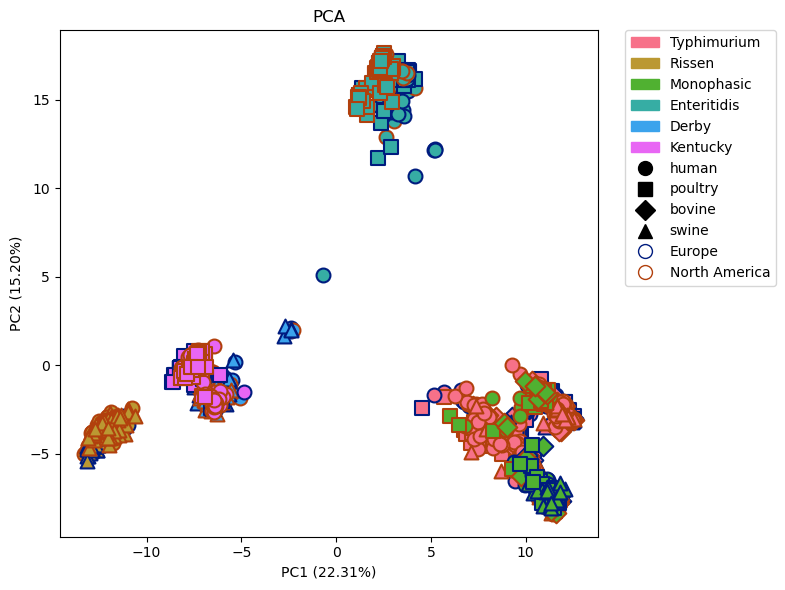

In [ ]:
# REVIEW: GitHub draft cell. Check relative paths and upstream variables before running end-to-end.
from sklearn.decomposition import PCA
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
#df = matrix
df = m
X = df.iloc[:,:-3]
X = X.iloc[:,1:]
#X = matrix.T.iloc[1:-1]
pca = PCA(n_components=2)

pca.fit(X)
X_reduced = pca.transform(X)
X_reduced_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2"])

#X_reduced_df['Name'] = matrix.T[0].iloc[1:-1].reset_index()['index'].reset_index(drop=True)
X_reduced_df['Name'] = matrix['Name'].reset_index(drop=True)
X_reduced_df['Source'] = m['sample_type'].reset_index(drop=True)
X_reduced_df['Origin'] = m['origin'].reset_index(drop=True)
X_reduced_df = X_reduced_df[X_reduced_df['Origin'] != 'Unknown']
X_reduced_df = X_reduced_df[X_reduced_df['Source'] != 'Unknown']
X_reduced_df = X_reduced_df.dropna(subset=['Name'])
X_reduced_df['Name'] = (X_reduced_df['Name']
    .str.replace('mono', 'Monophasic', regex=False)
    .str.replace('ent', 'Enteritidis', regex=False)
    .str.replace('ken', 'Kentucky', regex=False)
    .str.replace('der', 'Derby', regex=False)
    .str.replace('rissen', 'Rissen', regex=False)
    .str.replace('typhimurium', 'Typhimurium', regex=False)
)
X_reduced_df['Origin'] = (X_reduced_df['Origin'].str.replace('USA', 'North America', regex=False))

#X_reduced_df['Label'] = label
names = X_reduced_df['Name'].unique()
sources = X_reduced_df['Source'].unique()
origins = X_reduced_df['Origin'].unique()


# Create color palettes and marker mappings.
color_palette = dict(zip(names, sns.color_palette("husl", len(names))))
# Define a marker for each sample type. Adjust markers if you have more than 4 types.
marker_options = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X']
marker_dict = {source: marker_options[i] for i, source in enumerate(sources)}
edge_palette = dict(zip(origins, sns.color_palette("dark", len(origins))))

plt.figure(figsize=(8, 6))
# Loop through the DataFrame and plot each point individually
for idx, row in X_reduced_df.iterrows():
    plt.scatter(row['PC1'], row['PC2'],
                color=color_palette[row['Name']],         # fill color from Name
                marker=marker_dict[row['Source']],          # marker shape from sample_type
                edgecolor=edge_palette[row['Origin']],      # edge color from origin
                s=100,                                      # adjust point size if needed
                linewidth=1.5)

# --- Custom Legends ---
# Create legend handles for each aesthetic:
# 1. Fill color (Name)
color_handles = [mpatches.Patch(color=color_palette[name], label=name) for name in names]
# 2. Marker shape (Source)
marker_handles = [mlines.Line2D([], [], color='black', marker=marker_dict[source],
                                linestyle='None', markersize=10, label=source) for source in sources]
# 3. Edge color (Origin) – here we show an unfilled circle with the edge color.
edge_handles = [mlines.Line2D([], [], color=edge_palette[origin], marker='o',
                              linestyle='None', markerfacecolor='none', markersize=10, label=origin) for origin in origins]

# Combine all handles in one legend.
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA")
plt.legend(handles=color_handles + marker_handles + edge_handles,
           bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig('/hpc/group/G_BIOSCIENZE/giovanni.merici/pca_meta.png', dpi=300)
plt.show()

# Support Vector Machine

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM params: {'kernel': 'linear', 'gamma': 1, 'degree': 2, 'C': 10}
Accuracy (test): 1.000
Cohen's Kappa: 1.000
ROC AUC: 1.000
CV scores: [1. 1. 1. 1. 1.]
Mean CV accuracy: 1.0


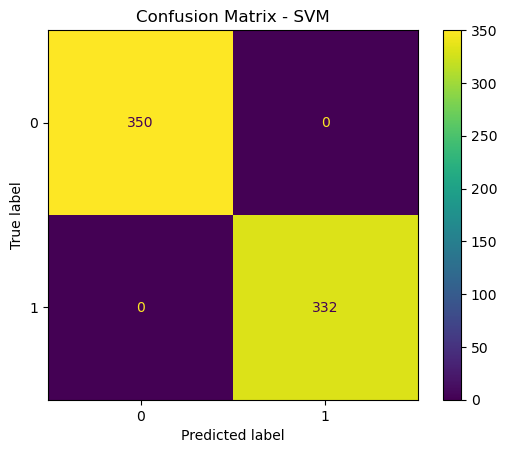

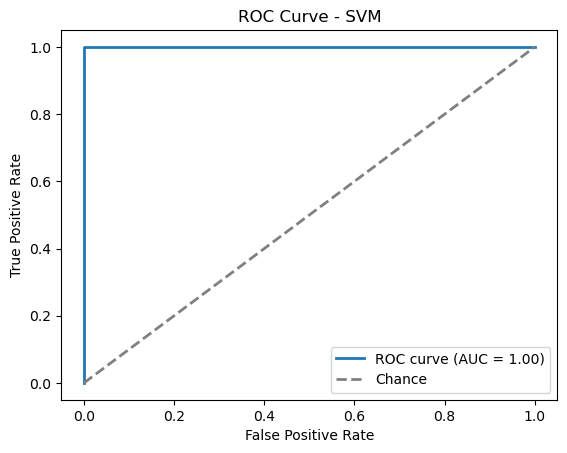

In [ ]:


from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, cohen_kappa_score
import matplotlib.pyplot as plt
import numpy as np

# --- Data prep ---
df = matrix.copy()
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

# Split (same as RF)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

# --- Hyperparameter search ---
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "degree": [1, 2, 3, 4]  # useful only if kernel="poly"
}

svm = SVC(probability=True)  # probability=True so we can get ROC curves
grid = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    random_state=0,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best SVM params:", grid.best_params_)

# --- Evaluate on train/test ---
y_pred = grid.best_estimator_.predict(X_test)
y_score = grid.best_estimator_.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_score)

print(f"Accuracy (test): {accuracy:.3f}")
print(f"Cohen's Kappa: {kappa:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")

# --- Cross-validation performance ---
cv_scores = cross_val_score(grid.best_estimator_, X_train, y_train, cv=5, scoring="accuracy")
print("CV scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix - SVM")
plt.show()

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure()
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--', color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")
plt.show()


In [ ]:

coefs = grid.best_estimator_.coef_[0]

svm_importances = pd.DataFrame({
    "coef": coefs,
    "abs_coef": np.abs(coefs),
    "feat": X.columns
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

In [ ]:

svm_importances = svm_importances[svm_importances['abs_coef'] > 0]
svm_importances

,coef,abs_coef,feat
0,1.066034e-02,1.066034e-02,STMMW_10141
1,1.066034e-02,1.066034e-02,STMMW_30781
2,-1.066034e-02,1.066034e-02,SNSL254_RS11450
3,-1.066034e-02,1.066034e-02,SNSL254_RS11435
4,-1.066034e-02,1.066034e-02,SNSL254_RS11460
...,...,...,...
6424,-1.734723e-18,1.734723e-18,STMMW_15801
6425,-1.734723e-18,1.734723e-18,STMMW_15931
6426,-1.734723e-18,1.734723e-18,STMMW_15921
6427,-1.734723e-18,1.734723e-18,STMMW_15771


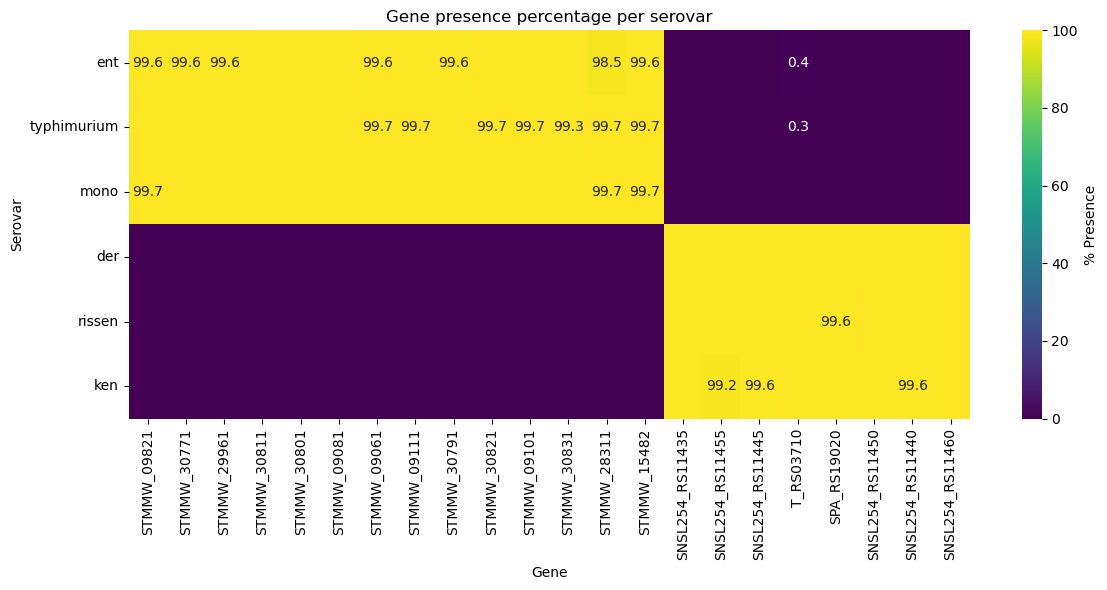

In [ ]:
# REVIEW: GitHub draft cell. Check relative paths and upstream variables before running end-to-end.
desired_order = ['ent', 'typhimurium', 'mono', 'der', 'rissen','ken']
ordered_percentage = percentage.loc[desired_order]

# Apply same mask for annotations if needed
rounded = ordered_percentage.round(1)
annot = rounded.astype(str)
annot[(rounded == 0.0) | (rounded == 100.0)] = ''

plt.figure(figsize=(12, 6))
sns.heatmap(rounded, cmap='viridis', annot=annot, fmt="", cbar_kws={'label': '% Presence'})

plt.title('Gene presence percentage per serovar')
plt.xlabel('Gene')
plt.ylabel('Serovar')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_22_genes_dataset_percentage_ordered.png', dpi=300)
plt.show()

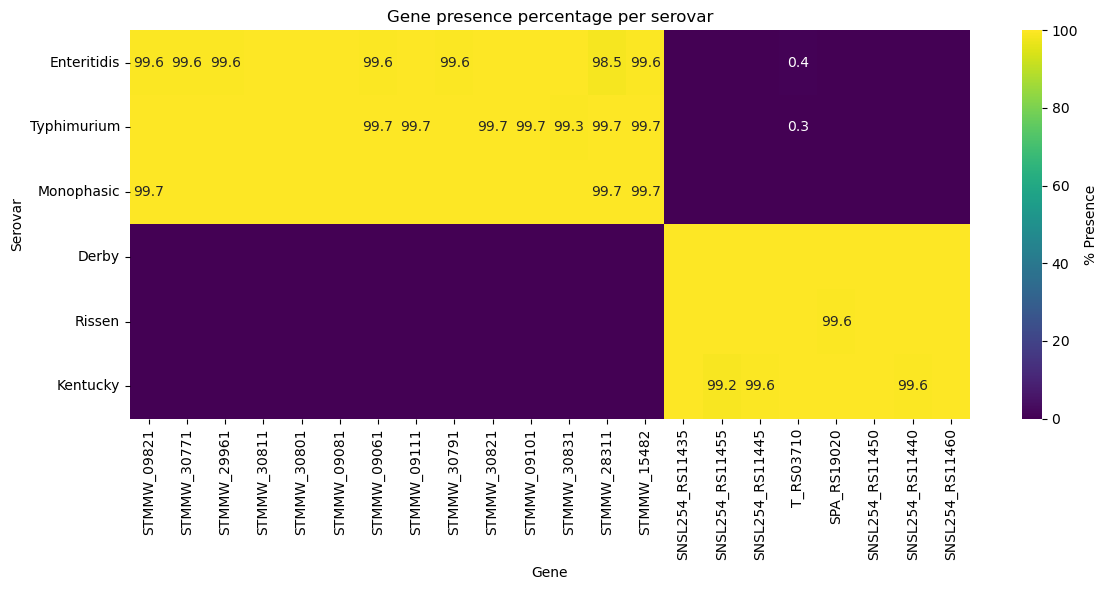

In [ ]:

# Map short names to full names
name_map = {
    'ent': 'Enteritidis',
    'typhimurium': 'Typhimurium',
    'mono': 'Monophasic',
    'der': 'Derby',
    'rissen': 'Rissen',
    'ken': 'Kentucky'
}

# Rename index labels
rounded.index = [name_map.get(serovar, serovar) for serovar in rounded.index]
annot.index = rounded.index  # sync annotation labels

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(rounded, cmap='viridis', annot=annot, fmt="", cbar_kws={'label': '% Presence'})

plt.title('Gene presence percentage per serovar')
plt.xlabel('Gene')
plt.ylabel('Serovar')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_22_genes_dataset_percentage_ordered_named.png', dpi=300)
plt.show()


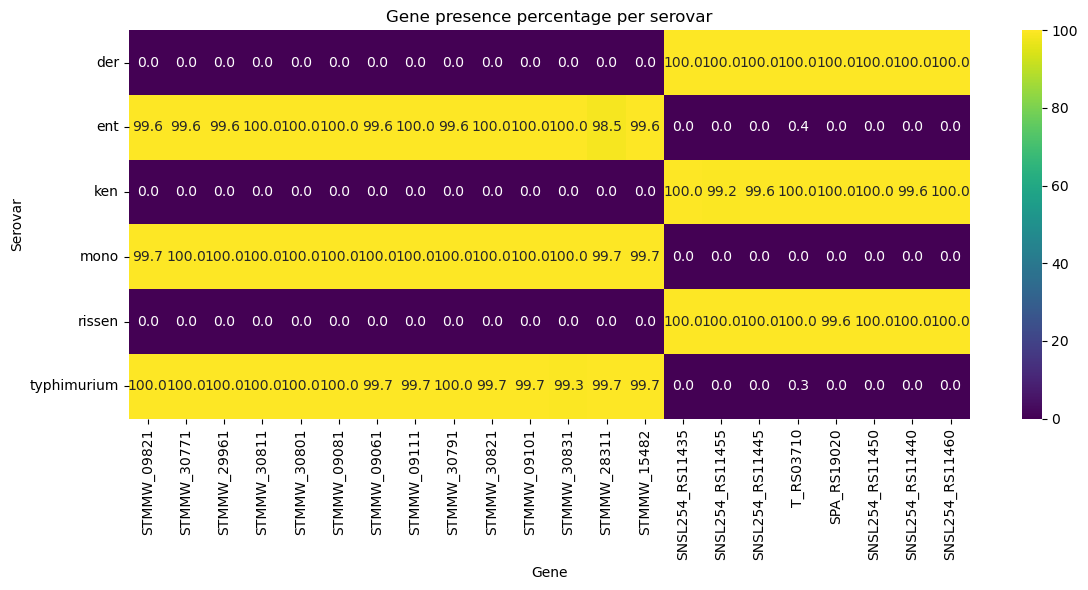

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(percentage, cmap='viridis', annot=True, fmt=".1f")  # show 1 decimal

plt.title('Gene presence percentage per serovar')  # <-- updated title
plt.xlabel('Gene')
plt.ylabel('Serovar')
plt.yticks(rotation=0)
plt.tight_layout()
#plt.savefig('heatmap_22_genes_dataset_percentage.png', dpi=300)
plt.show()
